<a href="https://www.kaggle.com/code/shauryasinghr/notebookab316d8122?scriptVersionId=190148067" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fast-food-sales-report/Balaji Fast Food Sales.csv
/kaggle/input/fast-food-sales-report/category distribution.JPG


In [2]:
#import necessary librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing dataset

In [3]:
df=pd.read_csv("/kaggle/input/fast-food-sales-report/Balaji Fast Food Sales.csv")

In [4]:
df.head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
5,6,11/14/2022,Vadapav,Fastfood,20,10,200,Cash,Mr.,Evening
6,7,05-03-2022,Sugarcane juice,Beverages,25,9,225,Cash,Mr.,Evening
7,8,12/22/2022,Panipuri,Fastfood,20,14,280,Online,Mr.,Night
8,9,06-10-2022,Panipuri,Fastfood,20,1,20,Cash,Mrs.,Morning
9,10,9/16/2022,Panipuri,Fastfood,20,5,100,Online,Mr.,Afternoon


In [5]:
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [6]:
df['transaction_type'].unique()

array([nan, 'Cash', 'Online'], dtype=object)

In [7]:
df['transaction_type'].mode()

0    Cash
Name: transaction_type, dtype: object

In [8]:
df['transaction_type']=df['transaction_type'].fillna('Cash')

In [9]:
df.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df=df.rename(columns={'received_by':'Gender'})

In [12]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,Gender,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    1000 non-null   object
 8   Gender              1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB


In [14]:
df['Gender']=df['Gender'].replace({'Mr.':'Male','Mrs.':'Female'})

In [15]:
df.isna().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
Gender                0
time_of_sale          0
dtype: int64

In [16]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,Gender,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Male,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Male,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Male,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Male,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Male,Evening


In [17]:
df['date']=df['date'].str.replace('/','-')

df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,Gender,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Male,Night
1,2,8-23-2022,Vadapav,Fastfood,20,15,300,Cash,Male,Afternoon
2,3,11-20-2022,Vadapav,Fastfood,20,1,20,Cash,Male,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Male,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Male,Evening


In [18]:
df['date']=pd.to_datetime(df['date'],format='%m-%d-%Y')

In [19]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,Gender,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,Cash,Male,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Male,Afternoon
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Male,Afternoon
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Male,Night
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Male,Evening


The basic data cleaning is complete for data analysis


In [20]:
df.groupby('item_type')['transaction_amount'].sum()

item_type
Beverages     86390
Fastfood     188840
Name: transaction_amount, dtype: int64

From above we found that more revenue is generated through fast food

Text(0.5, 1.0, 'Most_Selling_Category')

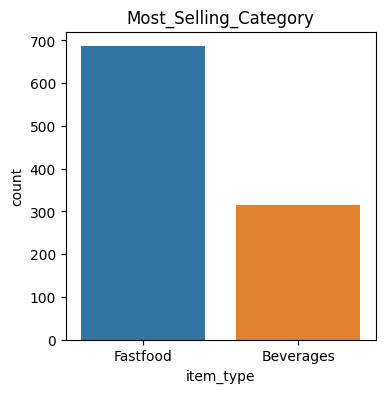

In [21]:
plt.figure(figsize=(4,4))
sns.countplot(x='item_type',data=df)
plt.title('Most_Selling_Category')

Fastfood are more sold as comapre to beverages

Text(0, 0.5, 'Count')

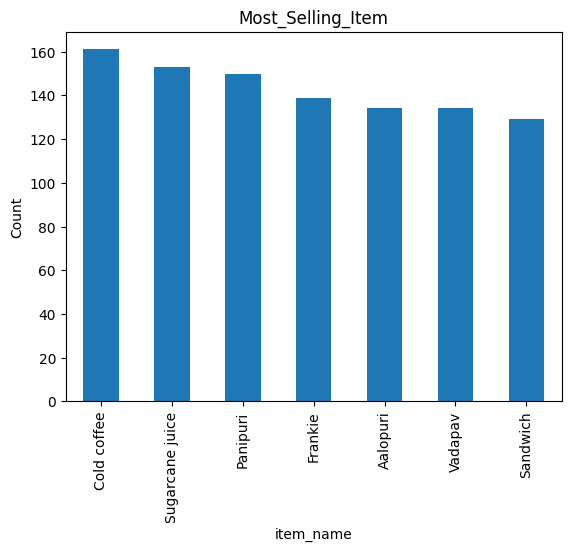

In [22]:
df['item_name'].value_counts().plot(kind='bar')
plt.title('Most_Selling_Item')
plt.ylabel('Count')

Out of all these items cold coffee is most sold and sandwitch is least sold items.

Text(0.5, 1.0, 'Most_profitable_Item')

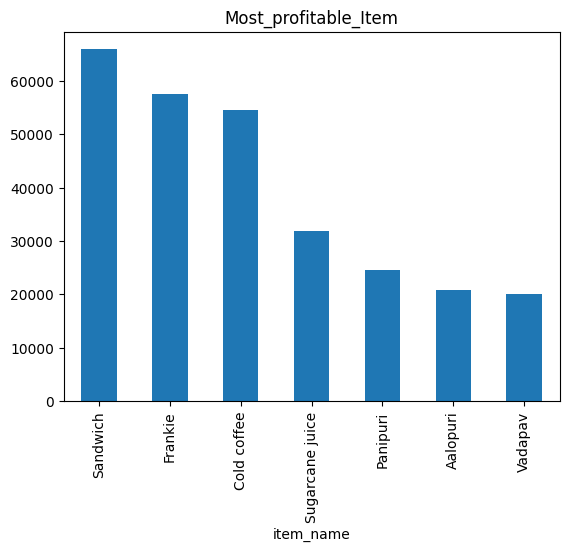

In [23]:
df.groupby('item_name')['transaction_amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Most_profitable_Item')

But here is the point, despite having the least sold item ,most revenue is generated through sandwitch and least revenue is from Vadapav. 

Text(0.5, 1.0, 'Transaction_type_count')

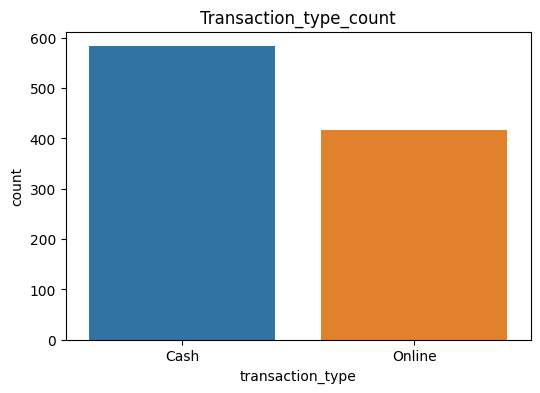

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='transaction_type',data=df)
plt.title('Transaction_type_count')

Text(0.5, 1.0, 'Gender')

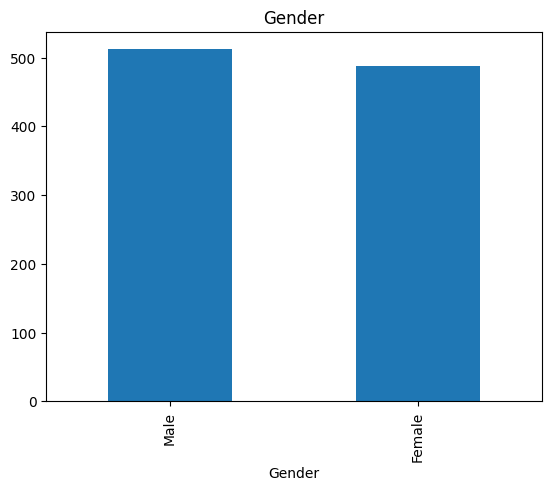

In [25]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender')

<Axes: xlabel='item_name,time_of_sale'>

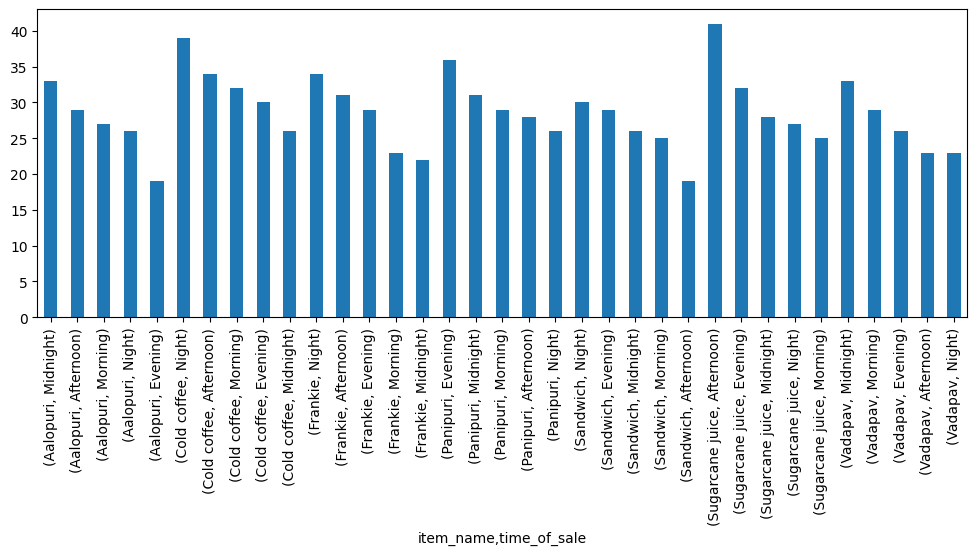

In [26]:
df.groupby('item_name')['time_of_sale'].value_counts().plot(kind='bar',figsize=(12,4))

From above graph we see that, Aalopuri most sold at midnight and least at evening,cold coffee most sold at night and least at midnight, Frankie most sold at night and least at midnight, Panipuri most sold at evening and least at night, Sandwitch most sold at night and least at afternoon, Sugarcane juice most sold at afternoon and least at morning and Vadapav most sold at midnight and least at night 

Text(0.5, 1.0, 'Time_Of_Sale')

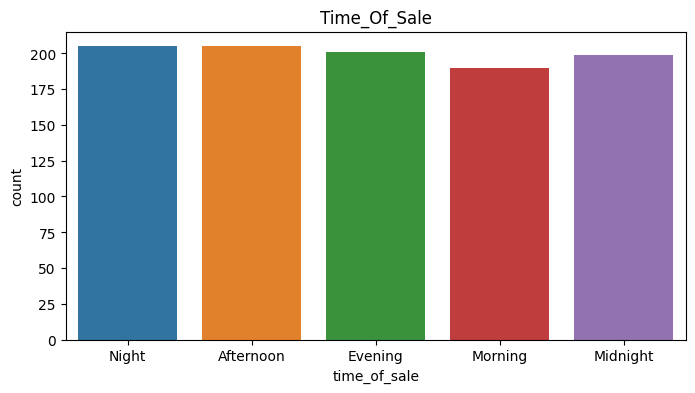

In [27]:
plt.figure(figsize=(8,4))
sns.countplot(x='time_of_sale',data=df)
plt.title('Time_Of_Sale')

Almost sale is same all over the day.

In [28]:
#year
df['Year']=df['date'].dt.year
#months
df['month']=df['date'].dt.month_name()

In [29]:
rev_by_year=df.groupby('Year')['transaction_amount'].sum()
print(rev_by_year)

Year
2022    195575
2023     79655
Name: transaction_amount, dtype: int64


In [30]:
rev_by_month=df.groupby('month')['transaction_amount'].sum()
print(rev_by_month)

month
April        17670
August       22305
December     23460
February     25595
January      28670
July         19490
June         17335
March        25390
May          26570
November     22900
October      27205
September    18640
Name: transaction_amount, dtype: int64


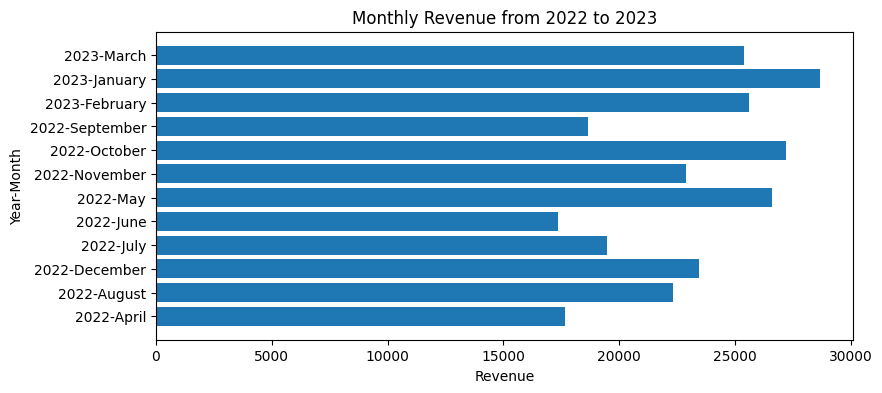

In [31]:
monthly_revenue = df.groupby(['Year', 'month'])['transaction_amount'].sum()

# Reset the index to make 'order_year' and 'order_month' as columns
monthly_revenue = monthly_revenue.reset_index()

# Plot the revenue monthwise
plt.figure(figsize=(9, 4))
plt.barh(
    range(len(monthly_revenue)),
    monthly_revenue['transaction_amount'],
    tick_label=monthly_revenue.apply(lambda x: f'{x["Year"]}-{x["month"]}', axis=1),
)
plt.xlabel('Revenue')
plt.ylabel('Year-Month')
plt.title('Monthly Revenue from 2022 to 2023')
plt.show()

Thanks for reading ,if you find any mistake please help me to learn.